In [2]:
pip install lifelines pandas matplotlib seaborn jupyter

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from lifelines import KaplanMeierFitter, CoxPHFitter
from lifelines.statistics import logrank_test
df=pd.read_csv('data/WA_Fn-UseC_-HR-Employee-Attrition.csv')

print(df.shape)
print(df.dtypes)
print(df.head())


(1470, 35)
Age                          int64
Attrition                   object
BusinessTravel              object
DailyRate                    int64
Department                  object
DistanceFromHome             int64
Education                    int64
EducationField              object
EmployeeCount                int64
EmployeeNumber               int64
EnvironmentSatisfaction      int64
Gender                      object
HourlyRate                   int64
JobInvolvement               int64
JobLevel                     int64
JobRole                     object
JobSatisfaction              int64
MaritalStatus               object
MonthlyIncome                int64
MonthlyRate                  int64
NumCompaniesWorked           int64
Over18                      object
OverTime                    object
PercentSalaryHike            int64
PerformanceRating            int64
RelationshipSatisfaction     int64
StandardHours                int64
StockOptionLevel             int64
TotalWork

YearsAtCompany (Time until event)
Attrition (did they leave?)
Department, JobRole, OverTime, JobSatisfaction (predictors)

Attrition_rate: 0.161
Avg years at company: 7.01


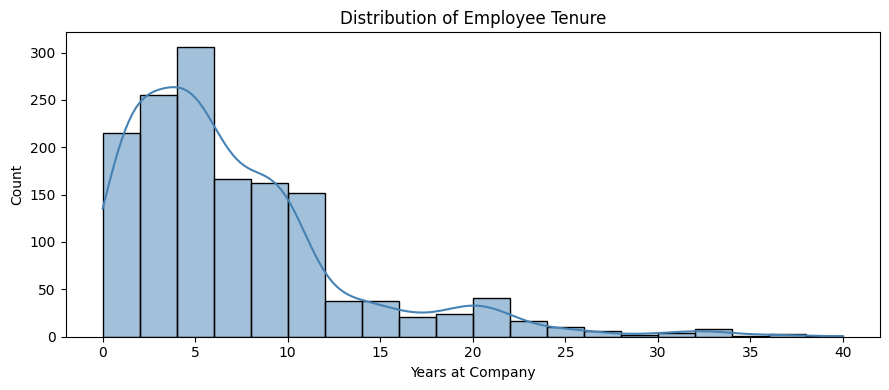

In [4]:
#Converting Attrition 
df['Attrition_binary']=df['Attrition'].apply(lambda x: 1 if x=='Yes' else 0)

# Quick Summary
print("Attrition_rate:",df['Attrition_binary'].mean().round(3))
print("Avg years at company:", df['YearsAtCompany'].mean().round(2))

# Distribution of tenure
plt.figure(figsize=(9, 4))
sns.histplot(df['YearsAtCompany'], bins=20, kde=True, color='steelblue')
plt.title('Distribution of Employee Tenure')
plt.xlabel('Years at Company')
plt.tight_layout()
plt.savefig('visuals/tenure_distribution.png', dpi=150)
plt.show()

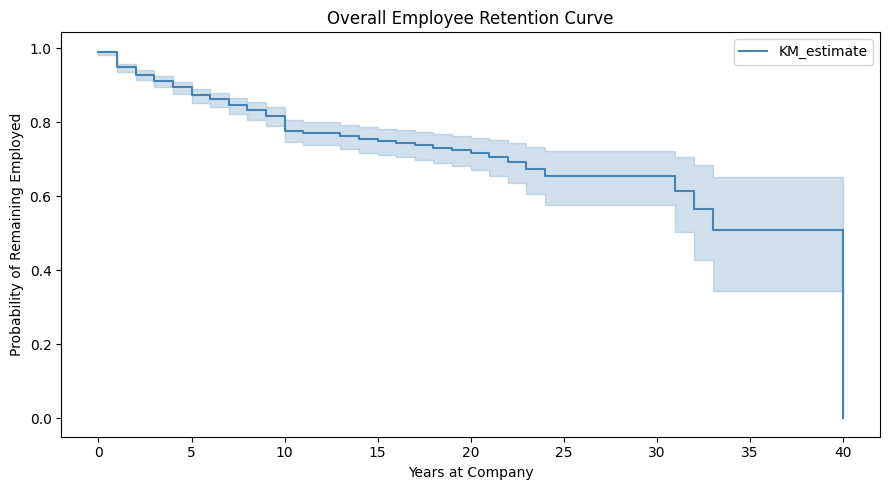

Median survival time: 40.0 years


In [5]:
kmf = KaplanMeierFitter()
kmf.fit(durations=df['YearsAtCompany'], event_observed=df['Attrition_binary'])
plt.figure(figsize=(9, 5))
kmf.plot_survival_function(color='steelblue')
plt.title('Overall Employee Retention Curve')
plt.xlabel('Years at Company')
plt.ylabel('Probability of Remaining Employed')
plt.tight_layout()
plt.savefig('visuals/km_overall.png', dpi=150)
plt.show()

print(f"Median survival time: {kmf.median_survival_time_} years")

The KM curve shows the probability that an employee remains with the company over time. The median survival time indicates that 50% of employees who leave do so within X years.

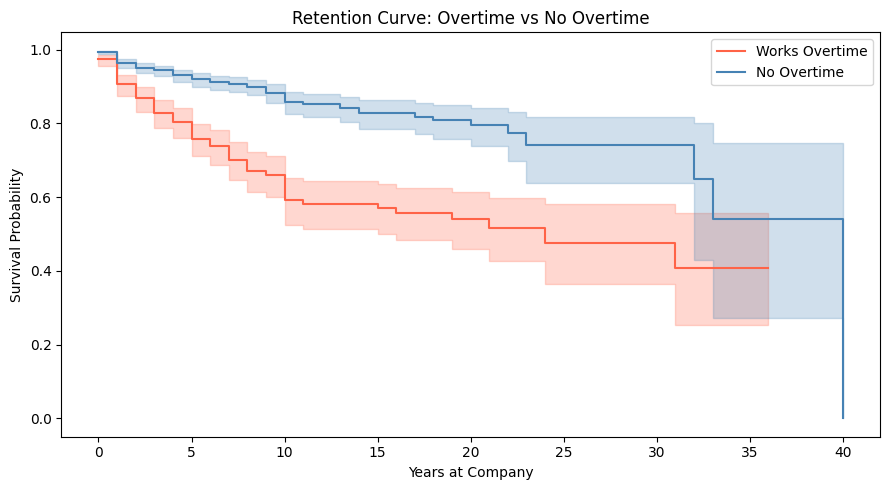

Log-rank p-value: 0.0000


In [6]:
#Comparing by OverTime
fig, ax = plt.subplots(figsize=(9, 5))

for group, label, color in [('Yes', 'Works Overtime', 'tomato'),
                              ('No', 'No Overtime', 'steelblue')]:
    mask = df['OverTime'] == group
    kmf.fit(df.loc[mask, 'YearsAtCompany'],
            event_observed=df.loc[mask, 'Attrition_binary'],
            label=label)
    kmf.plot_survival_function(ax=ax, color=color)

plt.title('Retention Curve: Overtime vs No Overtime')
plt.xlabel('Years at Company')
plt.ylabel('Survival Probability')
plt.tight_layout()
plt.savefig('visuals/km_overtime.png', dpi=150)
plt.show()

# Log-rank test
ot_yes = df[df['OverTime'] == 'Yes']
ot_no = df[df['OverTime'] == 'No']

result = logrank_test(ot_yes['YearsAtCompany'], ot_no['YearsAtCompany'],
                      event_observed_A=ot_yes['Attrition_binary'],
                      event_observed_B=ot_no['Attrition_binary'])
print(f'Log-rank p-value: {result.p_value:.4f}')

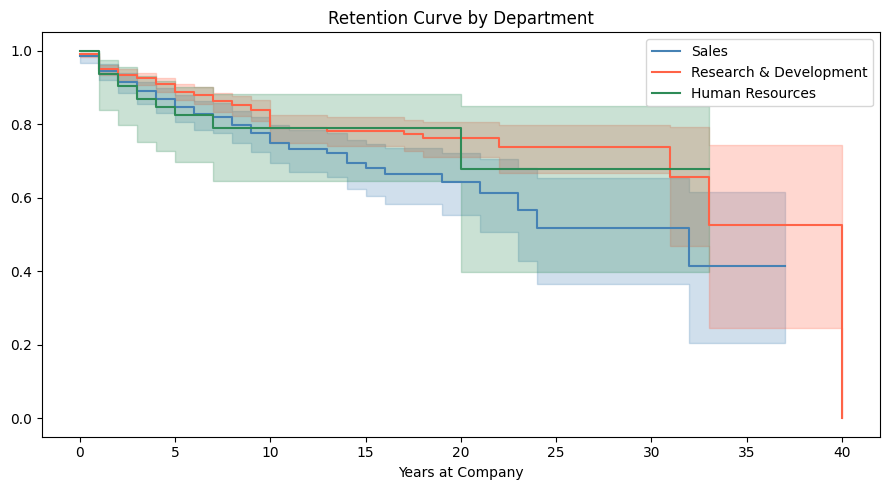

In [7]:
#Comparing by Department
fig, ax = plt.subplots(figsize=(9, 5))
colors = ['steelblue', 'tomato', 'seagreen']

for dept, color in zip(df['Department'].unique(), colors):
    mask = df['Department'] == dept
    kmf.fit(df.loc[mask, 'YearsAtCompany'],
            event_observed=df.loc[mask, 'Attrition_binary'],
            label=dept)
    kmf.plot_survival_function(ax=ax, color=color)

plt.title('Retention Curve by Department')
plt.xlabel('Years at Company')
plt.tight_layout()
plt.savefig('visuals/km_department.png', dpi=150)
plt.show()

<lifelines.CoxPHFitter: fitted with 1470 total observations, 1233 right-censored observations>
             duration col = 'YearsAtCompany'
                event col = 'Attrition_binary'
      baseline estimation = breslow
   number of observations = 1470
number of events observed = 237
   partial log-likelihood = -1424.80
         time fit was run = 2026-06-17 05:09:26 UTC

---
                                   coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                                          
Age                               -0.06      0.95      0.01           -0.08           -0.04                0.93                0.97
MonthlyIncome                     -0.23      0.80      0.03           -0.29           -0.17                0.75                0.84
JobSatisfaction                   -0.27      0.77      0.06           -0.38           -0.15                0.68                0.86
OverTime                           1.17      3.24      0.13            0.92            1.43                2.50                4.19
WorkLifeBalance                   -0.25      0.78      0.09           -0.43           -0.07                0.65                0.94
Department_Research & Development -0.36      0.70      0.30           -0.96            0.23                0.38                1.26
Department_Sales                   0.31      1.36      0.31           -0.30            0.92                0.74                2.51

                                   cmp to     z      p  -log2(p)
covariate                                                       
Age                                  0.00 -5.46 <0.005     24.33
MonthlyIncome                        0.00 -7.92 <0.005     48.57
JobSatisfaction                      0.00 -4.54 <0.005     17.45
OverTime                             0.00  8.97 <0.005     61.50
WorkLifeBalance                      0.00 -2.67   0.01      7.04
Department_Research & Development    0.00 -1.19   0.23      2.10
Department_Sales                     0.00  0.99   0.32      1.64
---
Concordance = 0.82
Partial AIC = 2863.61
log-likelihood ratio test = 298.64 on 7 df
-log2(p) of ll-ratio test = 199.08

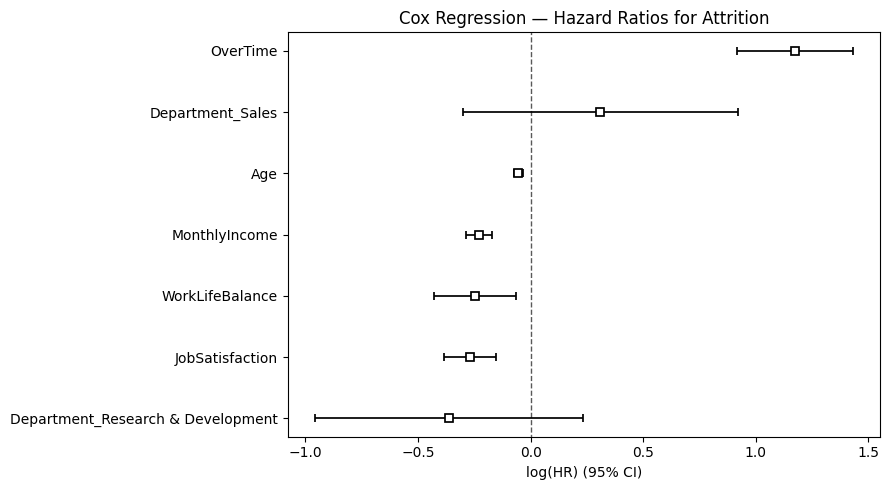

In [9]:
# Cox Proportional Hazards Model
# Select and encode variables
cox_cols = ['YearsAtCompany', 'Attrition_binary', 'Age',
            'MonthlyIncome', 'JobSatisfaction',
            'OverTime', 'Department', 'WorkLifeBalance']

cox_df = df[cox_cols].copy()
cox_df['MonthlyIncome'] = cox_df['MonthlyIncome'] / 1000
# Encode categoricals
cox_df['OverTime'] = (cox_df['OverTime'] == 'Yes').astype(int)
cox_df = pd.get_dummies(cox_df, columns=['Department'], drop_first=True)

# Fit Cox model
cph = CoxPHFitter()
cph.fit(cox_df, duration_col='YearsAtCompany', event_col='Attrition_binary')

cph.print_summary()

# Plot hazard ratios
plt.figure(figsize=(9, 5))
cph.plot()
plt.title('Cox Regression — Hazard Ratios for Attrition')
plt.tight_layout()
plt.savefig('visuals/cox_hazard_ratios.png', dpi=150)
plt.show()

Hazard ratios above 1 indicate factors that increase the risk of attrition. Overtime work shows a hazard ratio of X, meaning employees working overtime are X times more likely to leave at any given point in time. Monthly income has a protective effect (HR < 1), suggesting higher earners are more likely to stay.